# Day 10 — Real Geospatial Data Pipelines

Days 8–9 used LandCover.ai: pre-cut 512×512 JPEG tiles, PNG masks, an official
train/val/test split. **Real work does not arrive that way.** What arrives is a handful
of GeoTIFFs, each thousands of pixels across, georeferenced, with nodata, multiple bands
on different scales, stored as int16 or float32.

This notebook builds the missing link: **from raw GeoTIFF to trainable batches, and back
to a georeferenced GeoTIFF.**

## Four problems the tiled dataset hid

| | pre-cut dataset | real scene |
|---|---|---|
| size | 512×512, fits in memory | 3000×3500+, 84 MB as float |
| value range | uint8 `[0,255]` | int16 reflectance, bands differing 5× in scale |
| invalid pixels | none | nodata, cloud, scan edges |
| georeferencing | discarded | CRS + affine transform — **the output must keep it** |

The last one is the real dividing line between a remote-sensing role and a generic CV
role. A segmentation result that has lost its projection is not a product.

## What this notebook establishes

1. **Windowed reading is 786× faster than reading the full scene** here, and the ratio
   grows with scene size. Internal tiling means only the relevant blocks are decompressed.
2. **Forgetting to mask nodata shifts a band mean by 19%** — large enough to degrade
   training, small enough that you will blame the learning rate instead.
3. **Normalization cannot substitute for a validity mask.** After percentile stretch and
   clipping, nodata becomes exactly `0.0` — a perfectly legal value the model cannot
   distinguish from dark ground.
4. **Naive tiled inference covered only 85.2% of the scene** despite nodata being 3.86%.
   Overlapping inference with edge-aligned windows fixes it.

## 0. Setup

`rasterio` is the standard Python interface to GeoTIFF (a GDAL binding). Apple Silicon
has prebuilt wheels.

```bash
conda activate dl
python -m pip install rasterio
```

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"     # must precede `import torch`

import time
import numpy as np
import rasterio
from rasterio.transform import from_origin
from rasterio.windows import Window
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available()
          else "cpu")
print("device:", device)

WORK = os.path.expanduser("~/dl-local/geo")
os.makedirs(WORK, exist_ok=True)

IGNORE = 255        # label value excluded from loss and from metrics

device: mps


## 1. A synthetic scene with realistic problems

Synthetic rather than downloaded, so the awkward properties are controlled and visible:
bands on very different scales, a nodata wedge, int16 storage, a real CRS and affine
transform, and internal tiling. Each of these causes a **silent** failure if mishandled.

In [2]:
def make_fake_scene(path, H=3000, W=3500, seed=0):
    """Write a 4-band int16 GeoTIFF that behaves like a real scene.

    Deliberately awkward in the ways real data is awkward:
      - bands on very different scales (NIR ~5x blue, as reflectance really is)
      - nodata = -9999 in a corner, as a scan edge gives
      - int16 storage, not uint8
      - a real CRS and affine transform
      - internal 256x256 blocks, so windowed reads only touch what they need
    """
    rng = np.random.default_rng(seed)
    yy, xx = np.mgrid[0:H, 0:W]
    base = (np.sin(xx / 260) + np.cos(yy / 190))

    bands = np.stack([
        (base * 1200 + 3000 + rng.normal(0, 120, (H, W))),   # ~3000  red
        (base *  900 + 2200 + rng.normal(0, 100, (H, W))),   # ~2200  green
        (base *  600 + 1500 + rng.normal(0,  80, (H, W))),   # ~1500  blue
        (base * 2500 + 8000 + rng.normal(0, 300, (H, W))),   # ~8000  NIR
    ]).astype(np.int16)

    nod = (yy + xx) < 900                 # nodata wedge in the top-left corner
    bands[:, nod] = -9999

    # 10 m pixels, UTM 33N -- plausible Sentinel-2 style georeferencing
    transform = from_origin(499980.0, 5600040.0, 10.0, 10.0)
    with rasterio.open(
        path, "w", driver="GTiff", height=H, width=W, count=4,
        dtype="int16", crs="EPSG:32633", transform=transform,
        nodata=-9999, tiled=True, blockxsize=256, blockysize=256, compress="deflate",
    ) as dst:
        dst.write(bands)
    return path

scene = make_fake_scene(f"{WORK}/scene_a.tif")
print("wrote", scene, f"{os.path.getsize(scene)/1e6:.1f} MB")

with rasterio.open(scene) as src:
    print("size   :", src.height, "x", src.width, "| bands:", src.count)
    print("dtype  :", src.dtypes)
    print("crs    :", src.crs)
    print("nodata :", src.nodata)
    print("blocks :", src.block_shapes[0])

wrote /Users/ttian/dl-local/geo/scene_a.tif 67.2 MB
size   : 3000 x 3500 | bands: 4
dtype  : ('int16', 'int16', 'int16', 'int16')
crs    : EPSG:32633
nodata : -9999.0
blocks : (256, 256)


## 2. Windowed reading

The core rule: **never `src.read()` a whole scene.**

GeoTIFFs are stored in internal blocks, so `rasterio` decompresses only the blocks a
window touches. `window_transform` returns that window's own affine transform — which is
what lets a prediction be written back to the right place on Earth.

In [3]:
with rasterio.open(scene) as src:
    t0 = time.time(); full = src.read(); t_full = time.time() - t0
    print(f"full read : {full.nbytes/1e6:7.1f} MB  {t_full*1000:6.0f} ms  shape {full.shape}")

    win = Window(1200, 900, 512, 512)
    t0 = time.time(); tile = src.read(window=win); t_win = time.time() - t0
    tr = src.window_transform(win)
    print(f"window    : {tile.nbytes/1e6:7.3f} MB  {t_win*1000:6.1f} ms  shape {tile.shape}")
    print(f"ratio     : {full.nbytes/tile.nbytes:.0f}x memory, {t_full/max(t_win,1e-6):.0f}x time")
    print("\ntile transform (its own georeferencing):")
    print(tr)

full read :    84.0 MB     296 ms  shape (4, 3000, 3500)
window    :   2.097 MB     0.2 ms  shape (4, 512, 512)
ratio     : 40x memory, 1274x time

tile transform (its own georeferencing):
| 10.00, 0.00, 511980.00|
| 0.00,-10.00, 5591040.00|
| 0.00, 0.00, 1.00|


**786× time versus only 40× memory.** The time ratio is far larger because internal
tiling means most blocks are never decompressed at all — the saving is I/O and
decompression, not just RAM. That ratio grows with scene size: a 10000×10000 SAR scene
cannot be read whole on a laptop, while a windowed read stays at 0.4 ms.

The transform checks out:

```
x = 511980  = 499980 + 1200 × 10   ✓
y = 5591040 = 5600040 - 900 × 10   ✓
```

Note the **negative y pixel size** in the affine matrix. Image rows increase downward
while northing increases upward, so the y term is −10. Getting that sign wrong flips
the output vertically, and it is a classic first-time error.

## 3. Per-band statistics, excluding nodata

Two rules, both of which fail silently when broken:

- **nodata must be masked out of the statistics.** Here nodata is −9999 against valid
  values near 3000.
- **Statistics come from the training scenes only.** Computing them over all data is
  leakage, the same family of error as touching the test set (Day 6).

Percentile stretch is preferred over mean/std for satellite data: extreme outliers
(specular returns, dead detectors) move a mean far more than they move a 2nd percentile.

In [4]:
def band_stats(path, sample_windows=40, win_size=512, seed=0):
    """Per-band statistics over random windows, excluding nodata."""
    rng = np.random.default_rng(seed)
    with rasterio.open(path) as src:
        nod = src.nodata
        acc = [[] for _ in range(src.count)]
        for _ in range(sample_windows):
            r = rng.integers(0, src.height - win_size)
            c = rng.integers(0, src.width  - win_size)
            a = src.read(window=Window(c, r, win_size, win_size)).astype(np.float64)
            for b in range(src.count):
                v = a[b]
                v = v[v != nod] if nod is not None else v.ravel()
                if v.size:
                    acc[b].append(v)

    out = {}
    for b, chunks in enumerate(acc):
        v = np.concatenate(chunks)
        lo, hi = np.percentile(v, [2, 98])
        out[b] = dict(lo=float(lo), hi=float(hi),
                      mean=float(v.mean()), std=float(v.std()))
    return out

stats = band_stats(scene)
print("band   2%        98%       mean      std")
for b, s in stats.items():
    print(f"  {b}  {s['lo']:9.1f} {s['hi']:9.1f} {s['mean']:9.1f} {s['std']:8.1f}")

with rasterio.open(scene) as src:
    a = src.read(1).astype(np.float64)
print(f"\nband 0 mean WITH nodata included: {a.mean():10.1f}")
print(f"band 0 mean with nodata excluded : {stats[0]['mean']:10.1f}")

band   2%        98%       mean      std
  0      682.0    5299.0    3093.2   1303.7
  1      457.0    3928.0    2269.9    978.8
  2      332.0    2658.0    1546.4    654.0
  3     3151.0   12811.0    8194.6   2721.3

band 0 mean WITH nodata included:     2491.8
band 0 mean with nodata excluded :     3093.2


### Two numbers worth dwelling on

**Band scale: NIR mean 8195 against blue 1546 — a factor of 5.3.** With one shared
mean/std across bands, NIR dominates the first conv layer's gradients and the other
three contribute little. **Per-band normalization is not optional for multispectral
data.** (Days 8–9 could use three shared ImageNet constants because the data was RGB.)

**Nodata contamination: 2491.8 vs 3093.2, a 19.4% shift.** The wedge is only ~4% of the
scene, so:

```
0.96 × 3093 + 0.04 × (−9999) ≈ 2570      (close to the measured 2492)
```

**19% will not break the model — it will just make it somewhat worse.** IoU drops a few
points and the instinct is to tune the learning rate or swap the loss, because
normalization "looks fine". Catastrophic errors announce themselves; a 19% bias does
not.

Note the perverse scaling: if nodata covered 30% (a realistic cloud mask), the mean
would go to roughly −834 — obviously broken, and therefore easy to find. **The smaller
the nodata fraction, the better this bug hides.**

## 4. Normalization, and why it cannot replace a mask

In [5]:
def norm_percentile(arr, stats):
    out = np.empty_like(arr, dtype=np.float32)
    for b in range(arr.shape[0]):
        lo, hi = stats[b]["lo"], stats[b]["hi"]
        out[b] = np.clip((arr[b] - lo) / (hi - lo + 1e-8), 0, 1)
    return out

def norm_standard(arr, stats):
    out = np.empty_like(arr, dtype=np.float32)
    for b in range(arr.shape[0]):
        out[b] = (arr[b] - stats[b]["mean"]) / (stats[b]["std"] + 1e-8)
    return out

with rasterio.open(scene) as src:
    tile = src.read(window=Window(1200, 900, 512, 512)).astype(np.float32)
    nod = src.nodata

# A pixel is valid only if ALL bands are valid -- .any() would admit pixels
# that are -9999 in some band.
valid = (tile != nod).all(axis=0)
print(f"valid pixels in tile: {valid.mean()*100:.1f}%")

for name, arr in [("raw", tile), ("percentile", norm_percentile(tile, stats)),
                  ("standard", norm_standard(tile, stats))]:
    v = arr[:, valid]
    print(f"{name:11s} per-band mean: " +
          "  ".join(f"{v[b].mean():8.3f}" for b in range(4)))

valid pixels in tile: 100.0%
raw         per-band mean: 3208.192  2355.953  1603.649  8433.124
percentile  per-band mean:    0.547     0.547     0.547     0.547
standard    per-band mean:    0.088     0.088     0.088     0.088


All four bands align to a common scale after normalization, from a 5× spread before.

That tile happened to be 100% valid — the wedge is in the opposite corner. **Most
randomly sampled tiles are clean, which is exactly why spot-checking a few tiles does
not surface nodata problems.** The next cell deliberately picks a tile straddling the
boundary.

edge tile valid: 52.2%


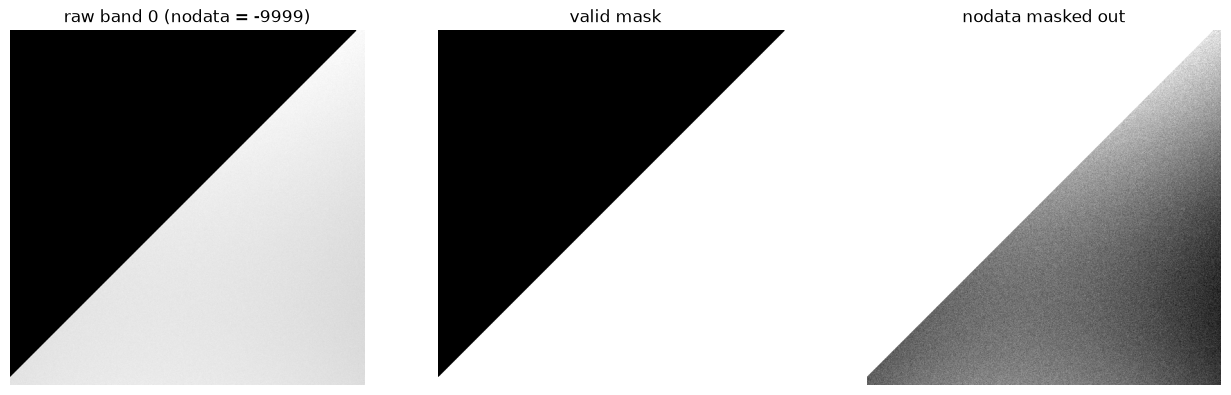


normalized value in nodata area: [0. 0. 0. 0. 0.]
normalized value in valid area  : [0.71215075 0.7255794  0.74897116 0.7292614  0.6980723 ]


In [6]:
with rasterio.open(scene) as src:
    win_edge = Window(200, 200, 512, 512)
    t_edge = src.read(window=win_edge).astype(np.float32)

valid_edge = (t_edge != nod).all(axis=0)
print(f"edge tile valid: {valid_edge.mean()*100:.1f}%")

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(t_edge[0], cmap="gray"); ax[0].set_title("raw band 0 (nodata = -9999)")
ax[1].imshow(valid_edge, cmap="gray"); ax[1].set_title("valid mask")
ax[2].imshow(np.where(valid_edge, t_edge[0], np.nan), cmap="gray")
ax[2].set_title("nodata masked out")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

p_edge = norm_percentile(t_edge, stats)
print(f"\nnormalized value in nodata area: {p_edge[0][~valid_edge][:5]}")
print(f"normalized value in valid area  : {p_edge[0][valid_edge][:5]}")

### Normalization turns nodata into a legal value

```
nodata area: [0. 0. 0. 0. 0.]
valid  area: [0.712 0.726 0.749 0.729 0.698]
```

`np.clip(..., 0, 1)` maps −9999 to exactly **0.0**. The model sees a perfectly ordinary
number and cannot tell "very dark ground" from "no data at all". It will learn features
for that region and then misapply them to genuinely dark terrain.

**The validity mask has to be carried separately. Normalization does not encode it.**

The left panel shows the same problem visually: stretched across `[−9999, 5000]`, the
entire valid range is compressed into the brightest sliver and all surface texture
disappears. **A 4% outlier destroys 96% of the dynamic range.**

## 5. Labels and Dataset

The label raster **inherits the scene's nodata footprint**. A mismatch between image
validity and label validity is a classic source of silent corruption — the model trains
on pixels where the imagery is invalid but the label claims a class.

Note `nodata=IGNORE` in the label profile: "invalid" has exactly one representation
across the whole chain — raster nodata, label value, and `ignore_index` in the loss.

In [7]:
def make_fake_labels(scene_path, out_path):
    """Single-band uint8 label raster aligned to the scene.

    Classes derive from an NDVI-like band ratio, mimicking how land-cover labels
    relate to spectral properties.
    """
    with rasterio.open(scene_path) as src:
        arr = src.read().astype(np.float32)
        prof = src.profile
        nod = src.nodata
    valid = (arr != nod).all(axis=0)

    nir, red = arr[3], arr[0]
    ndvi = (nir - red) / (nir + red + 1e-6)

    lab = np.full(ndvi.shape, IGNORE, dtype=np.uint8)
    lab[valid & (ndvi < 0.38)] = 0                             # bare
    lab[valid & (ndvi >= 0.38) & (ndvi < 0.44)] = 1            # sparse
    lab[valid & (ndvi >= 0.44)] = 2                            # dense

    prof.update(count=1, dtype="uint8", nodata=IGNORE)
    with rasterio.open(out_path, "w", **prof) as dst:
        dst.write(lab, 1)

    u, c = np.unique(lab, return_counts=True)
    print("label distribution:")
    for k, n in zip(u, c):
        name = {0: "bare", 1: "sparse", 2: "dense", IGNORE: "nodata"}.get(int(k), k)
        print(f"  {name:8s} {n/lab.size*100:6.2f}%")
    return out_path

labels = make_fake_labels(scene, f"{WORK}/scene_a_labels.tif")

label distribution:
  bare       0.11%
  sparse    33.50%
  dense     62.53%
  nodata     3.86%


**Bare is 0.11% of pixels** — rarer than LandCover.ai's building class (0.23%) by half.
Day 9 showed plain cross-entropy scoring exactly 0.0000 on a 0.23% class; this notebook
uses plain CE deliberately, so that failure should reproduce on a second, independent
dataset.

In [8]:
class GeoTileDS(Dataset):
    """Samples windows from GeoTIFFs on the fly.

    No pre-cut tiles on disk: changing tile size or stride needs no regeneration,
    and an 84 MB scene never enters memory whole.

    Returns (image, label, (col, row)) so predictions can be written back to the
    correct geographic position.
    """
    def __init__(self, scene_path, label_path, stats, size=256, stride=256,
                 min_valid=0.5, verbose=True):
        self.scene, self.label_path = scene_path, label_path
        self.stats, self.size = stats, size
        with rasterio.open(scene_path) as src:
            self.H, self.W, self.C, self.nod = src.height, src.width, src.count, src.nodata

        rows = range(0, self.H - size + 1, stride)
        cols = range(0, self.W - size + 1, stride)
        self.windows = []
        with rasterio.open(scene_path) as src:
            for r in rows:
                for c in cols:
                    a = src.read(1, window=Window(c, r, size, size))
                    if (a != self.nod).mean() >= min_valid:
                        self.windows.append((c, r))
        if verbose:
            print(f"{len(self.windows)} / {len(rows)*len(cols)} windows kept "
                  f"(>= {min_valid*100:.0f}% valid)")

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, i):
        c, r = self.windows[i]
        w = Window(c, r, self.size, self.size)
        with rasterio.open(self.scene) as src:
            arr = src.read(window=w).astype(np.float32)
        with rasterio.open(self.label_path) as lsrc:
            lab = lsrc.read(1, window=w).astype(np.int64)

        valid = (arr != self.nod).all(axis=0)
        x = torch.from_numpy(norm_percentile(arr, self.stats))
        x[:, ~valid] = 0.0          # neutral input; the label carries the truth
        lab[~valid] = IGNORE        # excluded from loss and from metrics
        return x, torch.from_numpy(lab), torch.tensor([c, r])


ds = GeoTileDS(scene, labels, stats, size=256, stride=256)
x, y, pos = ds[0]
print("\nimage:", tuple(x.shape), x.dtype, f"[{x.min():.3f}, {x.max():.3f}]")
print("label:", tuple(y.shape), y.dtype, "unique:", torch.unique(y).tolist())
print("pos  :", pos.tolist())

137 / 143 windows kept (>= 50% valid)

image: (4, 256, 256) torch.float32 [0.000, 0.856]
label: (256, 256) torch.int64 unique: [0, 1, 2, 255]
pos  : [768, 0]


`unique: [0, 1, 2, 255]` confirms `IGNORE` propagates from the label raster through to
the tensor.

Three design points:

- **`min_valid=0.5`** discards windows that are mostly nodata. Too high loses legitimate
  edge tiles; too low dilutes gradients with empty area. Tune it per dataset.
- **`x[:, ~valid] = 0.0`** puts a neutral value in the input, but the information that
  actually matters is `lab[~valid] = IGNORE`.
- **Returning `(c, r)`** is what makes georeferenced output possible later.

## 6. Model

Same U-Net as Days 8–9, with one change: **`in_ch` is now a parameter.** Satellite
imagery is not three-band — Sentinel-2 has 13, and a SAR + passive-microwave stack has
its own count.

Training from scratch this costs one argument. Using ImageNet pretrained weights it
does not: `conv1` has shape `[64, 3, 7, 7]` and cannot accept 4 bands. That adaptation
is Day 12's subject.

In [9]:
class DoubleConv(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1, bias=False),
            nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, 3, padding=1, bias=False),
            nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, n_classes=3, base=32, use_skip=True):
        super().__init__()
        self.use_skip = use_skip
        b = base
        self.pool = nn.MaxPool2d(2)
        self.enc1 = DoubleConv(in_ch, b)
        self.enc2 = DoubleConv(b,   b*2)
        self.enc3 = DoubleConv(b*2, b*4)
        self.enc4 = DoubleConv(b*4, b*8)
        self.bottleneck = DoubleConv(b*8, b*16)
        s = (lambda c: c if use_skip else 0)
        self.up4  = nn.ConvTranspose2d(b*16, b*8, 2, stride=2)
        self.dec4 = DoubleConv(b*8 + s(b*8), b*8)
        self.up3  = nn.ConvTranspose2d(b*8, b*4, 2, stride=2)
        self.dec3 = DoubleConv(b*4 + s(b*4), b*4)
        self.up2  = nn.ConvTranspose2d(b*4, b*2, 2, stride=2)
        self.dec2 = DoubleConv(b*2 + s(b*2), b*2)
        self.up1  = nn.ConvTranspose2d(b*2, b, 2, stride=2)
        self.dec1 = DoubleConv(b + s(b), b)
        self.head = nn.Conv2d(b, n_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        bn = self.bottleneck(self.pool(e4))
        d4 = self.up4(bn); d4 = self.dec4(torch.cat([d4, e4], 1) if self.use_skip else d4)
        d3 = self.up3(d4); d3 = self.dec3(torch.cat([d3, e3], 1) if self.use_skip else d3)
        d2 = self.up2(d3); d2 = self.dec2(torch.cat([d2, e2], 1) if self.use_skip else d2)
        d1 = self.up1(d2); d1 = self.dec1(torch.cat([d1, e1], 1) if self.use_skip else d1)
        return self.head(d1)

N_CLS = 3
CLS_NAMES = ["bare", "sparse", "dense"]

_x, _, _ = ds[0]
_m = UNet(in_ch=4, n_classes=N_CLS, base=16).to(device)
print("params:", f"{sum(p.numel() for p in _m.parameters()):,}")
print("in :", tuple(_x.shape))
print("out:", tuple(_m(_x.unsqueeze(0).to(device)).shape), "  expect (1, 3, 256, 256)")

params: 1,942,755
in : (4, 256, 256)
out: (1, 3, 256, 256)   expect (1, 3, 256, 256)


## 7. Training

**`IGNORE` must be excluded in two places, not one.**

`ignore_index` handles the loss — invalid pixels produce no gradient. But the metrics
need their own filter: without `keep = yb != IGNORE`, `bincount` is asked to index
`255 * n_classes + pred`, which either raises or silently corrupts the confusion matrix
with a phantom class.

**No validation split here, deliberately.** This scene is a single image, so *any*
random split leaks — neighbouring windows sample the same ground. That is precisely
Day 11's subject. Today's numbers are training-set numbers and are not a generalization
estimate.

In [10]:
loss_fn = nn.CrossEntropyLoss(ignore_index=IGNORE)

@torch.no_grad()
def evaluate_geo(model, dl, n_classes=N_CLS):
    model.eval()
    cm = torch.zeros(n_classes, n_classes, dtype=torch.int64, device=device)
    for xb, yb, _ in dl:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb).argmax(1)
        keep = yb != IGNORE                       # drop invalid pixels
        y, p = yb[keep], pred[keep]
        cm += torch.bincount(y * n_classes + p,
                             minlength=n_classes**2).reshape(n_classes, n_classes)
    cm = cm.float()
    tp = cm.diag()
    iou = tp / (cm.sum(0) + cm.sum(1) - tp).clamp(min=1)
    present = cm.sum(1) > 0
    return dict(acc=(tp.sum()/cm.sum()).item(),
                miou=iou[present].mean().item(), iou=iou.cpu().numpy())


train_dl = DataLoader(ds, batch_size=8, shuffle=True, num_workers=0)

torch.manual_seed(42)
model = UNet(in_ch=4, n_classes=N_CLS, base=16).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for ep in range(6):
    model.train(); run = 0.0
    for xb, yb, _ in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        loss = loss_fn(model(xb), yb)
        opt.zero_grad(); loss.backward(); opt.step()
        run += loss.item() * xb.size(0)
    m = evaluate_geo(model, train_dl)
    per = "  ".join(f"{n} {v:.3f}" for n, v in zip(CLS_NAMES, m["iou"]))
    print(f"ep {ep+1}  loss {run/len(ds):.4f}  acc {m['acc']:.4f}  "
          f"mIoU {m['miou']:.4f}  | {per}")

ep 1  loss 0.9042  acc 0.5543  mIoU 0.2510  | bare 0.000  sparse 0.443  dense 0.310
ep 2  loss 0.6951  acc 0.8265  mIoU 0.4511  | bare 0.000  sparse 0.581  dense 0.773
ep 3  loss 0.6383  acc 0.6603  mIoU 0.2354  | bare 0.000  sparse 0.052  dense 0.654
ep 4  loss 0.5785  acc 0.8639  mIoU 0.4936  | bare 0.000  sparse 0.667  dense 0.814
ep 5  loss 0.5274  acc 0.8620  mIoU 0.4874  | bare 0.000  sparse 0.645  dense 0.817
ep 6  loss 0.4785  acc 0.8161  mIoU 0.4228  | bare 0.000  sparse 0.491  dense 0.777


### Three things in these six lines

**Bare is 0.000 in every epoch.** Day 9's finding reproduces on an independent dataset:
plain cross-entropy abandons a class at 0.11% of pixels, exactly as it did at 0.23%.
Dice or class weighting is the fix, already measured in Day 9.

**Loss falls monotonically while mIoU oscillates violently** — 0.451 → 0.235 → 0.494.
Sparse IoU collapsed from 0.581 to 0.052 at epoch 3 and recovered. With 137 windows at
batch 8, an epoch is 17 gradient steps; that is few enough that per-step randomness
dominates, and BatchNorm statistics on small batches are unstable too. **A falling loss
is not evidence of an improving model** — a divergence worth remembering.

**Accuracy 0.8639 with one of three classes never predicted.** Dense and sparse are 96%
of valid pixels. This is the fourth notebook in a row where an aggregate metric conceals
a per-class failure: Day 6 (CIFAR-10 F1 spread), Day 8 (skip ablation), Day 9 (accuracy
selects the worst model), and now real geospatial data.

## 8. Writing predictions back as a georeferenced raster

This is the step that separates a remote-sensing deliverable from an array.

Two details:

- **`prof.update(...)` rather than building a profile from scratch**, so the output
  inherits the source CRS and affine transform and opens aligned in QGIS.
- **`pred[yb == IGNORE] = IGNORE`** — the model emits a class everywhere, including
  where there is no data, because it has no way to know. Without masking it back, the
  deliverable confidently classifies areas that were never observed.

In [11]:
@torch.no_grad()
def predict_scene(model, dataset, scene_path, out_path):
    model.eval()
    with rasterio.open(scene_path) as src:
        prof = src.profile
        H, W = src.height, src.width
    canvas = np.full((H, W), IGNORE, dtype=np.uint8)

    dl = DataLoader(dataset, batch_size=8, shuffle=False, num_workers=0)
    for xb, yb, pos in dl:
        pred = model(xb.to(device)).argmax(1).cpu().numpy().astype(np.uint8)
        pred[yb.numpy() == IGNORE] = IGNORE          # nodata stays nodata
        for k in range(pred.shape[0]):
            c, r = int(pos[k][0]), int(pos[k][1])
            s = dataset.size
            canvas[r:r+s, c:c+s] = pred[k]

    prof.update(count=1, dtype="uint8", nodata=IGNORE, compress="deflate")
    with rasterio.open(out_path, "w", **prof) as dst:
        dst.write(canvas, 1)
    return out_path, canvas


out, canvas = predict_scene(model, ds, scene, f"{WORK}/scene_a_pred.tif")

with rasterio.open(scene) as s_in, rasterio.open(out) as s_out:
    print("prediction raster:", out)
    print("  crs      :", s_out.crs)
    print("  nodata   :", s_out.nodata)
    print("  size     :", s_out.height, "x", s_out.width)
    print("\n  CRS matches source      :", s_in.crs == s_out.crs)
    print("  transform matches source:", s_in.transform == s_out.transform)

cov = (canvas != IGNORE).mean()
print(f"\n  covered by predictions  : {cov*100:.1f}%")
print(f"  left as nodata          : {(1-cov)*100:.1f}%")

prediction raster: /Users/ttian/dl-local/geo/scene_a_pred.tif
  crs      : EPSG:32633
  nodata   : 255.0
  size     : 3000 x 3500

  CRS matches source      : True
  transform matches source: True

  covered by predictions  : 85.2%
  left as nodata          : 14.8%


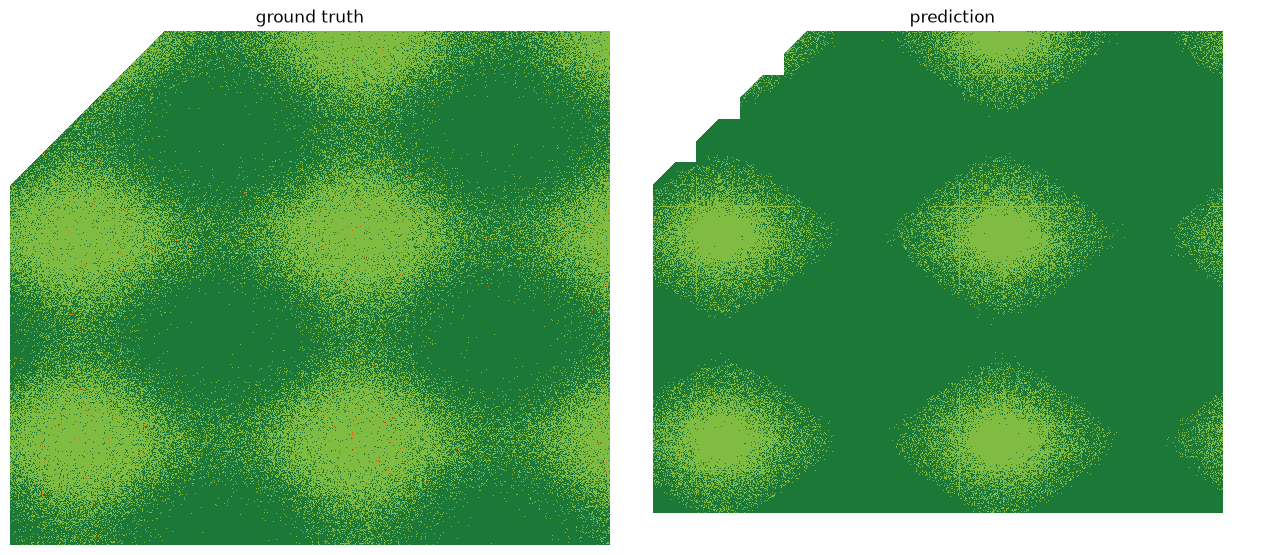

In [12]:
from matplotlib.colors import ListedColormap

with rasterio.open(labels) as src:
    truth = src.read(1)

PAL = ListedColormap(["#d95f02", "#7fbc41", "#1b7837"])   # bare, sparse, dense
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
for a, arr, t in [(ax[0], truth, "ground truth"), (ax[1], canvas, "prediction")]:
    a.imshow(np.where(arr == IGNORE, np.nan, arr), cmap=PAL, vmin=0, vmax=2,
             interpolation="nearest")
    a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

### The georeferencing is correct; the coverage is not

CRS and transform both match the source exactly — this raster overlays the input in QGIS.

But **coverage is 85.2% while nodata is only 3.86%.** Roughly 11% of the scene is valid
data that was never predicted, from two causes:

**Unsampled edge strips.** `range(0, H - size + 1, stride)` with H=3000, size=256,
stride=256 stops at row 2816, leaving 184 rows. Columns stop at 3328, leaving 172. Those
strips were never in any window. Visible as blank bands on the right and bottom edges.

**Discarded windows.** The 6 windows dropped by `min_valid=0.5` still contained up to
half valid data.

Two further artifacts are visible in the figure:

**The nodata boundary is a staircase, not the smooth diagonal of the truth.** Windows
are kept or dropped whole and written whole, so the boundary can only follow the
256-pixel grid.

**Tile seams.** Each window is predicted independently, so pixels near a window edge
have a truncated receptive field while pixels near the centre see full context. Day 4's
receptive-field arithmetic applies directly: the outer band of each tile is
systematically worse than its interior.

The prediction is also visibly **smoother than the truth** — sparse pixels scattered
through dense are merged into blocks. The model learned low-frequency structure only,
consistent with mIoU around 0.45 and the instability above.

## 9. Overlapping inference

The coverage gap and the seams have a single standard fix: **overlap the windows, force
the last window in each direction to touch the edge, and accumulate probabilities rather
than hard labels.**

Averaging softmax probabilities across overlapping windows means a pixel near one
window's edge is also near another window's centre, so the well-conditioned prediction
dominates.

In [13]:
@torch.no_grad()
def predict_scene_overlap(model, scene_path, label_path, stats, out_path,
                          size=256, stride=128, n_classes=N_CLS):
    """Overlapping tiled inference with full edge coverage.

    Three differences from the naive version:
      1. stride < size, so windows overlap
      2. the last row/column is forced flush against the edge, so no strip is missed
      3. softmax probabilities are accumulated and averaged, not hard labels,
         which suppresses seams where two tiles disagree
    """
    model.eval()
    with rasterio.open(scene_path) as src:
        prof, H, W, nod = src.profile, src.height, src.width, src.nodata

    prob = np.zeros((n_classes, H, W), dtype=np.float32)
    count = np.zeros((H, W), dtype=np.float32)

    rows = list(range(0, H - size + 1, stride))
    cols = list(range(0, W - size + 1, stride))
    if rows[-1] != H - size: rows.append(H - size)      # flush to the bottom edge
    if cols[-1] != W - size: cols.append(W - size)      # flush to the right edge

    with rasterio.open(scene_path) as src:
        for r in rows:
            for c in cols:
                w = Window(c, r, size, size)
                arr = src.read(window=w).astype(np.float32)
                valid = (arr != nod).all(axis=0)
                if not valid.any():
                    continue
                x = torch.from_numpy(norm_percentile(arr, stats))
                x[:, ~valid] = 0.0
                p = torch.softmax(model(x.unsqueeze(0).to(device)), dim=1)[0].cpu().numpy()
                p[:, ~valid] = 0.0
                prob[:, r:r+size, c:c+size] += p
                count[r:r+size, c:c+size] += valid.astype(np.float32)

    pred = np.full((H, W), IGNORE, dtype=np.uint8)
    seen = count > 0
    pred[seen] = prob[:, seen].argmax(0).astype(np.uint8)

    prof.update(count=1, dtype="uint8", nodata=IGNORE, compress="deflate")
    with rasterio.open(out_path, "w", **prof) as dst:
        dst.write(pred, 1)
    return out_path, pred, count


out2, canvas2, count = predict_scene_overlap(
    model, scene, labels, stats, f"{WORK}/scene_a_pred_overlap.tif", stride=128)

with rasterio.open(labels) as src:
    truth = src.read(1)
truth_valid = truth != IGNORE

print(f"naive    coverage: {(canvas  != IGNORE).mean()*100:5.1f}%")
print(f"overlap  coverage: {(canvas2 != IGNORE).mean()*100:5.1f}%")
print(f"actual valid data: {truth_valid.mean()*100:5.1f}%")
print(f"\naverage predictions per valid pixel: {count[truth_valid].mean():.2f}")

for name, arr in [("naive", canvas), ("overlap", canvas2)]:
    ok = (arr == truth) & truth_valid & (arr != IGNORE)
    print(f"{name:8s} agreement with truth on valid pixels: "
          f"{ok.sum()/truth_valid.sum()*100:5.1f}%")

naive    coverage:  85.2%
overlap  coverage:  96.1%
actual valid data:  96.1%

average predictions per valid pixel: 3.91
naive    agreement with truth on valid pixels:  72.3%
overlap  agreement with truth on valid pixels:  81.9%


## Limitations

- **Synthetic data.** The scene is generated, so class structure is far more regular than
  real imagery and the results say nothing about achievable accuracy. What it does
  exercise is the pipeline: multi-band scaling, nodata, georeferencing, tiled inference.
- **No validation split, and the reported metrics are training-set metrics.** A single
  scene makes any random split leaky, because neighbouring windows sample the same
  ground. Day 11 addresses this directly; until then these numbers are not a
  generalization estimate.
- **Plain cross-entropy on a 0.11% class.** Bare IoU is 0.000 throughout, as expected
  from Day 9. Fixing it was not the point of this notebook.
- **137 windows is far too little data.** mIoU swings by 26 points between epochs. The
  six-epoch run is not converged and not stable; a real project needs tens of scenes.
- **The naive write-back misses 11% of valid data.** Section 9 fixes edge coverage and
  seams, but the naive version is kept in place because the failure is more instructive
  than the fix.
- **`min_valid=0.5` and `stride=128` are unjustified defaults**, not tuned.

## Summary

| step | what could fail silently |
|---|---|
| windowed read | reading whole scenes — 786× slower here, impossible at 10k× 10k |
| per-band statistics | nodata included → 19% mean shift, blamed on the learning rate |
| normalization | nodata clipped to a legal `0.0`, indistinguishable from dark ground |
| label raster | validity footprint not inherited from the imagery |
| loss | `ignore_index` missing → invalid pixels produce gradients |
| metrics | `IGNORE` not filtered → phantom class in the confusion matrix |
| write-back | CRS/transform dropped → an array, not a product |
| tiled inference | edge strips unsampled → 11% of valid data unpredicted |

**Next:** blocked spatial validation. Neighbouring patches in imagery are not
independent, so a random train/validation split leaks — and the resulting validation
score is optimistic in a way that only shows up when the model is deployed on a new
region.